# HiDeNET → Inference Optimization Study (PyTorch)

**Goal:** measured, honest evidence of quantization, compression, profiling and inference optimization on a DeBERTa-v3 + 1D-CNN multilevel classifier.

The original HiDeNET (TensorFlow/Keras) never saved a checkpoint, so this notebook **re-implements it in PyTorch from the original notebook code (final training cell = paper config) and retrains it once**. Everything after that is the inference study.

| Part | What | Needs | Rough time |
|---|---|---|---|
| A | Rebuild split, re-implement HiDeNET in PyTorch, retrain, compare with the paper | GPU (Colab T4) | 15–30 min (frozen backbone) |
| B | FP32 baseline (CPU + GPU), profiler, backbone-vs-head breakdown | CPU (+GPU) | 20–40 min |
| C | Variants: dynamic INT8, `torch.compile`, fp16 autocast, ONNX Runtime FP32, ONNX Runtime INT8 | CPU (+GPU) | 1–2 h on Colab CPU |
| D | Results table, charts, README draft, resume bullet, zip bundle | – | 2 min |

**How to run:** Runtime → T4 GPU, then run top to bottom. Everything is cached to Drive (`results.json`, checkpoints, tokens), so after a Colab disconnect just re-run the cells; finished steps are skipped.

**Honest-framing rules baked in**
- Fixed inputs, fixed thread count, 10 warmup runs, p50/p95, batch sizes 1 and 16 (batch 1 = latency, batch 16 = throughput). Protocol is printed into the README.
- Every variant is also scored on the same held-out subset and compared with the FP32 baseline (prediction agreement + max prob difference). Failures are recorded, not hidden.
- Call it a *PyTorch re-implementation retrained on the same split*, not "the published checkpoint".

**About `FREEZE_BACKBONE`:** the original code has `for layer in deberta_model.layers[:6]: layer.trainable = False`. In the TF Hugging Face model `.layers` is most likely a single main-layer wrapper, so that loop probably froze the **whole** backbone (consistent with 45 min for 20 epochs). I could not verify it, so `FREEZE_BACKBONE = True` is an assumption. Training is cheap when frozen, so if your retrained numbers sit far from the paper's you can flip the flag and compare. Results are stored per tag (`deberta-v3-base_frozen` / `_finetuned`).

**Fallback for fragile variants:** if a DeBERTa variant fails (ONNX export, compile, quantization), the row is recorded as FAILED with the error. To get a comparison, set `MODEL_NAME = "distilbert-base-uncased"` in the config and re-run; results go to a separate folder.

In [1]:
# Colab already has torch. On a laptop, install torch yourself first.
!pip install -q transformers sentencepiece protobuf tiktoken onnx onnxruntime onnxscript matplotlib scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 16.9 MB/s eta 0:00:00


## 0. Config
All knobs live here. Paths follow your Drive layout (`Research/crypto-fire-analysis/train_data/cleaned_dataframe.csv`).

In [2]:
import os, sys, json, time, random, platform, subprocess, warnings, tempfile, gc
from pathlib import Path
warnings.filterwarnings("ignore")

# ---- paths ----
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_BASE = Path("/content/drive/MyDrive/Research/crypto-fire-analysis")
else:
    DRIVE_BASE = Path("./crypto-fire-analysis")      # laptop: put train_data/cleaned_dataframe.csv here
DATA_CSV = DRIVE_BASE / "train_data" / "cleaned_dataframe.csv"
WORK_DIR = DRIVE_BASE / "hidenet-inference-optimization"

# ---- model / training (paper Table III + notebook v7) ----
MODEL_NAME = "microsoft/deberta-v3-base"
FREEZE_BACKBONE = True        # assumption, see intro. Flip to False for full fine-tuning (slower, more memory)
MAX_LEN, EPOCHS, BATCH, LR = 256, 20, 16, 2e-5
FOCAL_GAMMA, FOCAL_ALPHAS = 2.0, (0.5, 0.25, 0.25)     # alpha: Level 1 = 0.5, Levels 2 and 3 = 0.25
USE_AMP = True                # fp16 autocast during training. Set False if the loss turns NaN.
SEED = 42

# ---- benchmark protocol ----
NUM_THREADS = min(4, os.cpu_count() or 1)   # plan says 4; Colab free CPU only has 2 vCPUs, so we cap at what exists
BENCH_BATCHES = (1, 16)
WARMUP = 10
ITERS_GPU = 100
ITERS_CPU = {1: 100, 16: 20}  # batch 16 on CPU is slow; 20 timed runs instead of 100 (documented in README)
EVAL_N = 500                  # accuracy/parity eval subset per variant (same subset for all). None = full test set (slow on CPU)

MODEL_SHORT = MODEL_NAME.split("/")[-1]
TAG = f"{MODEL_SHORT}_{'frozen' if FREEZE_BACKBONE else 'finetuned'}"
CKPT_DIR = WORK_DIR / "checkpoints"
RES_DIR = WORK_DIR / "results" / TAG
for d in (CKPT_DIR, RES_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("TAG:", TAG, "| results ->", RES_DIR)

Mounted at /content/drive
TAG: deberta-v3-base_frozen | results -> /content/drive/MyDrive/Research/crypto-fire-analysis/hidenet-inference-optimization/results/deberta-v3-base_frozen


In [3]:
import copy, contextlib, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import transformers, sklearn

def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_all()

torch.set_num_threads(NUM_THREADS)
HAS_CUDA = torch.cuda.is_available()
GPU_NAME = torch.cuda.get_device_name(0) if HAS_CUDA else None

def cpu_model_name():
    try:
        out = subprocess.check_output("lscpu", shell=True, text=True)
        for line in out.splitlines():
            if line.startswith("Model name"):
                return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

ENV = {"cpu": cpu_model_name(), "cpu_count": os.cpu_count(), "threads_used": NUM_THREADS, "gpu": GPU_NAME,
       "python": platform.python_version(), "torch": torch.__version__, "transformers": transformers.__version__,
       "scikit-learn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__}
try:
    import onnxruntime as ort, onnx
    ENV["onnxruntime"], ENV["onnx"] = ort.__version__, onnx.__version__
except Exception as e:
    print("onnx/onnxruntime import problem:", e)
(RES_DIR / "environment.json").write_text(json.dumps(ENV, indent=2))
print(json.dumps(ENV, indent=2))

{
  "cpu": "Intel(R) Xeon(R) CPU @ 2.20GHz",
  "cpu_count": 12,
  "threads_used": 4,
  "gpu": "NVIDIA A100-SXM4-40GB",
  "python": "3.13.15",
  "torch": "2.11.0+cu130",
  "transformers": "5.18.0",
  "scikit-learn": "1.6.1",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "onnxruntime": "1.30.0",
  "onnx": "1.23.1"
}


## Part A: Rebuild the split, re-implement HiDeNET, retrain

**Data.** Same recipe as the notebook: `StratifiedShuffleSplit(test_size=0.2, random_state=42)` on `label_level_1`. The split depends only on the labels, so it regenerates the original test split. Keras' `validation_split=0.1` takes the *last* 10% of the unshuffled training arrays, which is reproduced here.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import AutoModel, AutoTokenizer

df = pd.read_csv(DATA_CSV)
print("rows:", len(df), "(paper: 9263 after cleaning)")
assert df[["Text", "label_level_1", "label_level_2", "label_level_3"]].notna().all().all(), "null values in data"
texts = df["Text"].astype(str).tolist()
Y = np.stack([df["label_level_1"].values, df["label_level_2"].values, df["label_level_3"].values], axis=1).astype(np.int64)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(texts, Y[:, 0]))
n_fit = int(len(train_idx) * 0.9)                     # Keras validation_split=0.1 -> last 10% of training arrays
fit_idx, val_idx = train_idx[:n_fit], train_idx[n_fit:]
print(f"fit {len(fit_idx)} | val {len(val_idx)} | test {len(test_idx)} (paper Level-2 support: 1853)")
for k in range(3):
    print(f"test class counts level {k+1}:", np.bincount(Y[test_idx, k]).tolist())

np.savez(WORK_DIR / "split_indices.npz", train=train_idx, test=test_idx, fit=fit_idx, val=val_idx)
df.iloc[test_idx].to_csv(WORK_DIR / "test_split.csv")     # stays on Drive: do NOT commit dataset rows to GitHub

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
TOK_CACHE = WORK_DIR / f"tokens_{MODEL_SHORT}_len{MAX_LEN}.npz"
if TOK_CACHE.exists():
    z = np.load(TOK_CACHE); IDS, MASK = z["ids"], z["mask"]
    assert IDS.shape[0] == len(texts), "token cache does not match data; delete it"
else:
    enc = tok(texts, padding="max_length", truncation=True, max_length=MAX_LEN, return_tensors="np")
    IDS, MASK = enc["input_ids"].astype(np.int64), enc["attention_mask"].astype(np.int64)
    np.savez_compressed(TOK_CACHE, ids=IDS, mask=MASK)
print("tokens:", IDS.shape)
IDS_TEST, MASK_TEST, Y_TEST = IDS[test_idx], MASK[test_idx], Y[test_idx]

rows: 9263 (paper: 9263 after cleaning)
fit 6669 | val 741 | test 1853 (paper Level-2 support: 1853)
test class counts level 1: [351, 422, 1080]
test class counts level 2: [1618, 109, 126]
test class counts level 3: [1142, 499, 161, 51]


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokens: (9263, 256)


**Model.** Same architecture as the paper/notebook: backbone → `[CLS]` and `Conv1D(128, k=3, same) + ReLU + GlobalMaxPool` → concat (896) → `Dense(256) + ReLU + Dropout(0.3)` → three softmax heads (3 / 3 / 4). Loss: the notebook's focal loss (`alpha * (1-p)^gamma * -log p` on the true class, batch mean), summed over the three heads with equal weight. Weights use Glorot init like Keras.

In [5]:
class HiDeNET(nn.Module):
    def __init__(self, backbone, n_filters=128, dense=256, dropout=0.3, n_classes=(3, 3, 4), freeze_backbone=True):
        super().__init__()
        hidden = backbone.config.hidden_size
        self.backbone = backbone
        self.freeze_backbone = freeze_backbone
        self.conv = nn.Conv1d(hidden, n_filters, kernel_size=3, padding=1)     # Keras Conv1D(padding="same")
        self.fc = nn.Linear(hidden + n_filters, dense)
        self.drop = nn.Dropout(dropout)
        self.head1, self.head2, self.head3 = (nn.Linear(dense, c) for c in n_classes)
        for m in (self.conv, self.fc, self.head1, self.head2, self.head3):
            nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()          # frozen encoder: no dropout noise
        return self

    def forward(self, input_ids, attention_mask):
        h = self.backbone(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state   # (B, L, H)
        cls = h[:, 0]
        local = F.relu(self.conv(h.transpose(1, 2))).max(dim=2).values                            # GlobalMaxPooling1D
        z = self.drop(F.relu(self.fc(torch.cat([cls, local], dim=1))))
        return self.head1(z), self.head2(z), self.head3(z)                                       # logits (softmax applied in loss / eval)


def build_model(freeze_backbone=FREEZE_BACKBONE):
    # newer transformers can load the hub checkpoint in fp16 by default; force true FP32 weights
    backbone = AutoModel.from_pretrained(MODEL_NAME).float()
    return HiDeNET(backbone, freeze_backbone=freeze_backbone)


def focal_loss(logits, target, gamma=FOCAL_GAMMA, alpha=0.25, eps=1e-7):
    p = F.softmax(logits.float(), dim=-1).clamp(eps, 1 - eps)
    p_t = p.gather(1, target[:, None]).squeeze(1)
    return (-alpha * (1 - p_t) ** gamma * torch.log(p_t)).mean()


def total_loss(outs, y):
    return sum(focal_loss(o, y[:, i], alpha=FOCAL_ALPHAS[i]) for i, o in enumerate(outs))


def param_report(m):
    tot = sum(p.numel() for p in m.parameters())
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    emb = sum(p.numel() for n, p in m.named_parameters() if "embeddings" in n)
    head = sum(p.numel() for n, p in m.named_parameters() if not n.startswith("backbone."))
    print(f"total {tot/1e6:.1f}M | trainable {tr/1e6:.2f}M | embeddings {emb/1e6:.1f}M ({100*emb/tot:.0f}%) | "
          f"encoder {(tot-emb-head)/1e6:.1f}M | CNN+dense head {head/1e6:.2f}M")
    dts = {str(p.dtype) for p in m.parameters()}
    print("parameter dtypes:", dts)
    assert dts == {"torch.float32"}, f"expected pure FP32 weights, got {dts}"

_tmp = build_model()
param_report(_tmp)
del _tmp; gc.collect()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


total 184.4M | trainable 0.53M | embeddings 98.8M (54%) | encoder 85.1M | CNN+dense head 0.53M
parameter dtypes: {'torch.float32'}


1869

In [6]:
# ---- shared prediction + metrics helpers (used in training, evaluation and every variant) ----
def _pad_batch(a, bs):
    return a if len(a) == bs else np.concatenate([a, np.repeat(a[:1], bs - len(a), axis=0)], axis=0)

def predict_torch(m, ids, mask, device, bs=16, autocast=False):
    outs = [[], [], []]
    for i in range(0, len(ids), bs):
        n = len(ids[i:i + bs])
        b_ids = torch.from_numpy(_pad_batch(ids[i:i + bs], bs)).to(device)       # full batches only (avoids recompiles)
        b_mask = torch.from_numpy(_pad_batch(mask[i:i + bs], bs)).to(device)
        with torch.inference_mode():
            if autocast and device == "cuda":
                with torch.autocast("cuda", dtype=torch.float16):
                    o = m(b_ids, b_mask)
            else:
                o = m(b_ids, b_mask)
        for k in range(3):
            outs[k].append(o[k].float().cpu().numpy()[:n])
    return tuple(np.concatenate(x) for x in outs)

def head_metrics(logits3, y):
    out = {}
    for i in range(3):
        pred = logits3[i].argmax(1)
        out[f"acc_l{i+1}"] = float(accuracy_score(y[:, i], pred))
        out[f"f1_l{i+1}"] = float(f1_score(y[:, i], pred, average="macro", zero_division=0))
    return out

In [7]:
CKPT_FINAL = CKPT_DIR / f"hidenet_{TAG}_final.pt"
CKPT_RESUME = CKPT_DIR / f"hidenet_{TAG}_resume.pt"
DEVICE = "cuda" if HAS_CUDA else "cpu"

def make_loader(idx, shuffle):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(IDS[idx]), torch.from_numpy(MASK[idx]), torch.from_numpy(Y[idx]))
    return torch.utils.data.DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

def run_training():
    assert HAS_CUDA, "Training needs a GPU runtime (Runtime -> Change runtime type -> T4 GPU)"
    seed_all()
    model = build_model().to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=LR)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    hist, start = [], 0
    if CKPT_RESUME.exists():
        ck = torch.load(CKPT_RESUME, map_location="cpu")
        model.load_state_dict(ck["model"], strict=False)
        opt.load_state_dict(ck["opt"]); hist, start = ck["hist"], ck["epoch"]
        print(f"resumed after epoch {start}")
    fit_loader = make_loader(fit_idx, shuffle=True)
    for ep in range(start, EPOCHS):
        model.train(); t0 = time.time(); run, n = 0.0, 0
        for ids, mask, y in fit_loader:
            ids, mask, y = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_AMP):
                outs = model(ids, mask)
            loss = total_loss(outs, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            run += loss.item() * len(y); n += len(y)
        model.eval()
        vl = predict_torch(model, IDS[val_idx], MASK[val_idx], DEVICE, bs=64, autocast=USE_AMP)
        val_loss = float(total_loss([torch.from_numpy(a) for a in vl], torch.from_numpy(Y[val_idx])))
        vm = head_metrics(vl, Y[val_idx])
        rec = {"epoch": ep + 1, "train_loss": run / n, "val_loss": val_loss, "secs": time.time() - t0, **vm}
        hist.append(rec)
        print(f"ep {ep+1:2d}/{EPOCHS} train {rec['train_loss']:.4f} | val {val_loss:.4f} | val acc "
              f"{vm['acc_l1']:.3f}/{vm['acc_l2']:.3f}/{vm['acc_l3']:.3f} | {rec['secs']:.0f}s")
        keep = {k: v.detach().cpu() for k, v in model.state_dict().items()
                if not (model.freeze_backbone and k.startswith("backbone."))}
        torch.save({"model": keep, "opt": opt.state_dict(), "epoch": ep + 1, "hist": hist}, CKPT_RESUME)
    (RES_DIR / "train_history.json").write_text(json.dumps(hist, indent=2))
    torch.save({k: v.detach().cpu() for k, v in model.state_dict().items()}, CKPT_FINAL)   # full weights, portable
    print("saved", CKPT_FINAL)
    return model

model = build_model()
if CKPT_FINAL.exists():
    model.load_state_dict(torch.load(CKPT_FINAL, map_location="cpu"))
    print("loaded existing checkpoint:", CKPT_FINAL)
else:
    model = run_training()
model = model.cpu().eval()
torch.cuda.empty_cache() if HAS_CUDA else None

model.safetensors: reconstructing file:   0%|          |  0.00B /  371MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


loaded existing checkpoint: /content/drive/MyDrive/Research/crypto-fire-analysis/hidenet-inference-optimization/checkpoints/hidenet_deberta-v3-base_frozen_final.pt


### A.2 Compare with the paper
Final-epoch weights are evaluated on the full test split (as in the notebook, every head is scored on all test samples). The paper's reported Hamming losses imply accuracies of about 79.2 / 88.4 / 84.8 % (Hamming loss = 1 - accuracy for single-label heads), which is a better yardstick than the rounded accuracy figures in the text.

In [8]:
dev = "cuda" if HAS_CUDA else "cpu"
full_logits = predict_torch(model.to(dev), IDS_TEST, MASK_TEST, dev, bs=64, autocast=(USE_AMP and HAS_CUDA))
model = model.cpu().eval()
full = head_metrics(full_logits, Y_TEST)

PAPER_HAMMING = (0.2078, 0.1160, 0.1522)
print(f"{'':8s}{'ours acc':>10s}{'ours ham':>10s}{'paper ham':>11s}{'paper acc':>11s}{'ours F1':>9s}")
for i in range(3):
    a = full[f"acc_l{i+1}"]
    print(f"Level {i+1}  {a:10.4f}{1-a:10.4f}{PAPER_HAMMING[i]:11.4f}{1-PAPER_HAMMING[i]:11.4f}{full[f'f1_l{i+1}']:9.3f}")
print("paper macro-F1: Level 1 = 0.75, Level 3 = 0.65")

reports = []
for i in range(3):
    reports.append(f"=== Level {i+1} ===\n" + classification_report(Y_TEST[:, i], full_logits[i].argmax(1), zero_division=0))
print("\n".join(reports))
(RES_DIR / "hidenet_reimpl_metrics.json").write_text(json.dumps({**full, "n_test": int(len(test_idx)), "tag": TAG}, indent=2))
(RES_DIR / "hidenet_reimpl_classification_reports.txt").write_text("\n".join(reports))

          ours acc  ours ham  paper ham  paper acc  ours F1
Level 1      0.8046    0.1954     0.2078     0.7922    0.763
Level 2      0.8834    0.1166     0.1160     0.8840    0.410
Level 3      0.8332    0.1668     0.1522     0.8478    0.643
paper macro-F1: Level 1 = 0.75, Level 3 = 0.65
=== Level 1 ===
              precision    recall  f1-score   support

           0       0.67      0.66      0.66       351
           1       0.77      0.74      0.76       422
           2       0.86      0.88      0.87      1080

    accuracy                           0.80      1853
   macro avg       0.77      0.76      0.76      1853
weighted avg       0.80      0.80      0.80      1853

=== Level 2 ===
              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1618
           1       0.00      0.00      0.00       109
           2       0.92      0.17      0.29       126

    accuracy                           0.88      1853
   macro avg       0.60  

1244

**Sanity bar:** within a couple of points of the paper = faithful reproduction. If you are far off, check (1) the row count printed above is 9263, (2) try `FREEZE_BACKBONE = False`, (3) set `USE_AMP = False`. Whatever you end up with, report your own measured numbers next to the paper's.

## Part B: Measurement harness, FP32 baseline, profiling

Fixed inputs (first test examples, padded to 256 tokens so every variant sees identical shapes: a worst-case but fair setting), fixed thread count, warmup, p50/p95. Every variant is also scored on one fixed evaluation subset and compared with the FP32 CPU baseline.

In [9]:
def bench(fn, warmup=WARMUP, iters=100, cuda=False):
    for _ in range(warmup):
        fn()
    ts = []
    for _ in range(iters):
        if cuda: torch.cuda.synchronize()
        t = time.perf_counter()
        fn()
        if cuda: torch.cuda.synchronize()
        ts.append((time.perf_counter() - t) * 1000)
    return float(np.percentile(ts, 50)), float(np.percentile(ts, 95))

def run_latency(make_fn, device):
    lat = {}
    for bs in BENCH_BATCHES:
        iters = ITERS_GPU if device == "cuda" else ITERS_CPU[bs]
        lat[bs] = bench(make_fn(bs), WARMUP, iters, cuda=(device == "cuda"))
        print(f"  bs{bs}: p50 {lat[bs][0]:.1f} ms | p95 {lat[bs][1]:.1f} ms")
    return lat

def torch_fn_factory(m, device, autocast=False):
    def make(bs):
        ids = torch.from_numpy(IDS_TEST[:bs]).to(device); mask = torch.from_numpy(MASK_TEST[:bs]).to(device)
        def fn():
            with torch.inference_mode():
                if autocast:
                    with torch.autocast("cuda", dtype=torch.float16):
                        return m(ids, mask)
                return m(ids, mask)
        return fn
    return make

def size_mb_state_dict(m):
    p = Path(tempfile.gettempdir()) / "_size_probe.pt"
    torch.save(m.state_dict(), p); s = os.path.getsize(p) / 2 ** 20; p.unlink()
    return s

# ---- fixed evaluation subset (same for every variant) ----
rng = np.random.RandomState(SEED)
eval_pos = np.sort(rng.choice(len(test_idx), EVAL_N, replace=False)) if (EVAL_N and EVAL_N < len(test_idx)) else np.arange(len(test_idx))
EV_IDS, EV_MASK, EV_Y = IDS_TEST[eval_pos], MASK_TEST[eval_pos], Y_TEST[eval_pos]
print("eval subset size:", len(eval_pos), "| class counts L3:", np.bincount(EV_Y[:, 2], minlength=4).tolist(),
      "(small classes are noisy at this size; set EVAL_N=None for the full test set)")

# ---- results registry (persisted, so Colab disconnects do not lose work) ----
RESULTS_JSON = RES_DIR / "results.json"
results = json.loads(RESULTS_JSON.read_text()) if RESULTS_JSON.exists() else {}
def save_results(): RESULTS_JSON.write_text(json.dumps(results, indent=2))
def is_done(name): return results.get(name, {}).get("status") == "ok"

def _sm(x):
    e = np.exp(x - x.max(1, keepdims=True)); return e / e.sum(1, keepdims=True)

BASE_LOGITS = None
_BL = RES_DIR / "baseline_logits_cpu_fp32.npz"
if _BL.exists():
    z = np.load(_BL)
    if z["l1"].shape[0] == len(eval_pos):
        BASE_LOGITS = (z["l1"], z["l2"], z["l3"])

def record(name, device, size_mb, lat, logits3, notes="", extra=None):
    row = {"variant": name, "device": device, "status": "ok", "size_mb": round(float(size_mb), 1),
           "threads": NUM_THREADS if device == "cpu" else None}
    for bs, (p50, p95) in lat.items():
        row[f"bs{bs}_p50"], row[f"bs{bs}_p95"] = round(p50, 2), round(p95, 2)
    if 16 in lat:
        row["thr16_samples_s"] = round(16 / (lat[16][0] / 1000), 2)
    row.update({k: round(v, 4) for k, v in head_metrics(logits3, EV_Y).items()})
    if BASE_LOGITS is not None:
        for i in range(3):
            row[f"agree_l{i+1}"] = round(float((logits3[i].argmax(1) == BASE_LOGITS[i].argmax(1)).mean()) * 100, 2)
            row[f"maxdiff_l{i+1}"] = round(float(np.abs(_sm(logits3[i][:100]) - _sm(BASE_LOGITS[i][:100])).max()), 6)
    row["notes"] = notes
    if extra: row.update(extra)
    results[name] = row; save_results()
    return row

def record_failure(name, device, err):
    results[name] = {"variant": name, "device": device, "status": "FAILED", "notes": f"{type(err).__name__}: {str(err)[:300]}"}
    save_results(); print("FAILED:", name, "->", results[name]["notes"])

def show():
    cols = ["variant", "status", "size_mb", "bs1_p50", "bs1_p95", "bs16_p50", "bs16_p95", "acc_l1", "acc_l2", "acc_l3", "agree_l1", "agree_l2", "agree_l3"]
    d = pd.DataFrame(list(results.values()))
    return d[[c for c in cols if c in d.columns]]

eval subset size: 500 | class counts L3: [327, 124, 38, 11] (small classes are noisy at this size; set EVAL_N=None for the full test set)


In [10]:
# ---- Variant 0a: FP32 baseline on CPU (reference for size, latency and parity) ----
N_BASE = "FP32 baseline (CPU)"
base = model.cpu().eval()
assert {p.dtype for p in base.parameters()} == {torch.float32}, "baseline must be pure FP32 (re-run the model cell, then the load cell)"
if not is_done(N_BASE) or BASE_LOGITS is None:
    print(N_BASE, f"| threads={NUM_THREADS}")
    lat = run_latency(torch_fn_factory(base, "cpu"), "cpu")
    logits = predict_torch(base, EV_IDS, EV_MASK, "cpu", bs=16)
    BASE_LOGITS = logits
    np.savez(_BL, l1=logits[0], l2=logits[1], l3=logits[2])
    record(N_BASE, "cpu", size_mb_state_dict(base), lat, logits, notes="reference; agreement/maxdiff columns are measured against this row")
else:
    print("already done:", N_BASE)
BASE_SIZE = results[N_BASE]["size_mb"]
show()

FP32 baseline (CPU) | threads=4
  bs1: p50 241.8 ms | p95 316.4 ms
  bs16: p50 4157.9 ms | p95 4241.5 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.78,0.88,0.864,100.0,100.0,100.0


In [11]:
# ---- Variant 0b: FP32 baseline on GPU ----
N = "FP32 baseline (GPU)"
m_gpu = None
if HAS_CUDA:
    m_gpu = copy.deepcopy(base).to("cuda").eval()
    if not is_done(N):
        print(N, "|", GPU_NAME)
        lat = run_latency(torch_fn_factory(m_gpu, "cuda"), "cuda")
        logits = predict_torch(m_gpu, EV_IDS, EV_MASK, "cuda", bs=16)
        record(N, "cuda", BASE_SIZE, lat, logits, notes=GPU_NAME)
else:
    print("No GPU in this runtime: skipping GPU rows.")
show()

FP32 baseline (GPU) | NVIDIA A100-SXM4-40GB
  bs1: p50 22.3 ms | p95 23.9 ms
  bs16: p50 69.4 ms | p95 69.6 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.78,0.88,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.78,0.88,0.864,100.0,100.0,100.0


### B.2 Profiling
`torch.profiler` with `record_shapes=True`, a few iterations after warmup. Tables are saved to `results/`. Expectation to check against the output: linear layers (`aten::addmm` / matmul) and attention (`bmm`, softmax) dominate the encoder, and the Conv1D head is negligible.

In [12]:
from torch.profiler import profile, ProfilerActivity

def profile_fn(fn, device, tag, n_iter=5):
    acts = [ProfilerActivity.CPU] + ([ProfilerActivity.CUDA] if device == "cuda" else [])
    for _ in range(3): fn()
    if device == "cuda": torch.cuda.synchronize()
    with profile(activities=acts, record_shapes=True) as prof:
        for _ in range(n_iter): fn()
        if device == "cuda": torch.cuda.synchronize()
    sorts = ["self_cpu_time_total"] if device == "cpu" else ["self_device_time_total", "self_cuda_time_total"]
    txt = None
    for s in sorts:
        try:
            txt = prof.key_averages().table(sort_by=s, row_limit=12); break
        except Exception:
            continue
    (RES_DIR / f"profile_{tag}.txt").write_text(txt or "profiler table unavailable")
    rows = [(e.key, e.count, e.self_cpu_time_total) for e in prof.key_averages()]
    tot = sum(r[2] for r in rows) or 1
    share = pd.DataFrame(sorted(rows, key=lambda r: -r[2])[:12], columns=["op", "calls", "self_cpu_us"])
    share["pct_of_host_time"] = (100 * share.self_cpu_us / tot).round(1)
    share.to_csv(RES_DIR / f"profile_{tag}_top_ops.csv", index=False)
    print(f"--- {tag} ---"); print(share.to_string(index=False))
    return share

for bs in BENCH_BATCHES:
    profile_fn(torch_fn_factory(base, "cpu")(bs), "cpu", f"cpu_fp32_bs{bs}")
if HAS_CUDA:
    profile_fn(torch_fn_factory(m_gpu, "cuda")(16), "cuda", "gpu_fp32_bs16")

--- cpu_fp32_bs1 ---
                     op  calls  self_cpu_us  pct_of_host_time
            aten::addmm    500   733564.155              60.7
              aten::bmm    240   134423.023              11.1
            aten::copy_   1565    59864.977               5.0
           aten::gather    120    58812.882               4.9
              aten::add    485    34512.807               2.9
             aten::add_     60    16412.925               1.4
     aten::masked_fill_     60    15629.789               1.3
              aten::div    190    15563.335               1.3
         aten::_softmax     60    15189.577               1.3
             aten::gelu     60    12302.963               1.0
           aten::linear    500    10992.224               0.9
aten::native_layer_norm    130     9126.082               0.8
--- cpu_fp32_bs16 ---
                      op  calls  self_cpu_us  pct_of_host_time
             aten::addmm    500  7203123.700              41.7
               aten::bmm 

In [13]:
# ---- where does the time go? backbone vs CNN/dense head (CPU, FP32) ----
def bb_factory(m, device):
    def make(bs):
        ids = torch.from_numpy(IDS_TEST[:bs]).to(device); mask = torch.from_numpy(MASK_TEST[:bs]).to(device)
        def fn():
            with torch.inference_mode():
                return m.backbone(input_ids=ids, attention_mask=mask).last_hidden_state
        return fn
    return make

breakdown = {}
for bs in BENCH_BATCHES:
    it = 30 if bs == 1 else 8
    tot_p50, _ = bench(torch_fn_factory(base, "cpu")(bs), 3, it)
    bb_p50, _ = bench(bb_factory(base, "cpu")(bs), 3, it)
    breakdown[f"bs{bs}"] = {"total_ms": round(tot_p50, 2), "backbone_ms": round(bb_p50, 2), "backbone_share_pct": round(100 * bb_p50 / tot_p50, 1)}
print(json.dumps(breakdown, indent=2))
(RES_DIR / "backbone_breakdown.json").write_text(json.dumps(breakdown, indent=2))

{
  "bs1": {
    "total_ms": 236.55,
    "backbone_ms": 238.01,
    "backbone_share_pct": 100.6
  },
  "bs16": {
    "total_ms": 2583.03,
    "backbone_ms": 2580.94,
    "backbone_share_pct": 99.9
  }
}


202

## Part C: Optimizations (one at a time, re-measured)
Each cell is wrapped so a failure is **recorded with its error** and the notebook carries on. Keep every result, including the ones that do not help.

### C.1 Dynamic INT8 quantization (CPU)
`quantize_dynamic` on `nn.Linear` only: attention/FFN projections and the dense/head layers. The **Conv1D and the embedding table stay FP32**. The embedding table is roughly half of all parameters (see the param report above), so size shrinks less than a naive "4x" guess.

In [14]:
N = "Dynamic INT8 (CPU)"
if not is_done(N):
    try:
        print(N)
        qm = torch.ao.quantization.quantize_dynamic(copy.deepcopy(base).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
        n_q = sum(1 for m in qm.modules() if type(m).__module__.startswith("torch.ao.nn.quantized.dynamic"))
        print("quantized Linear modules:", n_q)
        lat = run_latency(torch_fn_factory(qm, "cpu"), "cpu")
        logits = predict_torch(qm, EV_IDS, EV_MASK, "cpu", bs=16)
        record(N, "cpu", size_mb_state_dict(qm), lat, logits,
               notes=f"torch.ao quantize_dynamic, {n_q} nn.Linear -> int8; Conv1d + embeddings stay FP32")
        del qm; gc.collect()
    except Exception as e:
        record_failure(N, "cpu", e)
else:
    print("already done:", N)
show()

Dynamic INT8 (CPU)
quantized Linear modules: 76
  bs1: p50 158.5 ms | p95 165.0 ms
  bs16: p50 3080.7 ms | p95 3111.4 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,158.46,165.01,3080.66,3111.42,0.396,0.872,0.660,42.0,98.6,69.6


### C.2 `torch.compile` (CPU and GPU)
The first call per input shape includes tracing and compilation. That time is **excluded from the latency numbers and reported separately** (`compile_s_bs1`, `compile_s_bs16`). DeBERTa has custom ops and may graph-break; if it fails, the error is recorded.

In [15]:
def compile_variant(name, src_model, device):
    if is_done(name):
        print("already done:", name); return
    try:
        print(name)
        torch._dynamo.reset()
        cm = torch.compile(src_model)
        factory, ctimes = torch_fn_factory(cm, device), {}
        def make(bs):
            fn = factory(bs)
            t = time.perf_counter(); fn()
            if device == "cuda": torch.cuda.synchronize()
            ctimes[bs] = time.perf_counter() - t
            print(f"  first call (compile) bs{bs}: {ctimes[bs]:.1f}s")
            return fn
        lat = run_latency(make, device)
        logits = predict_torch(cm, EV_IDS, EV_MASK, device, bs=16)
        record(name, device, BASE_SIZE, lat, logits, notes="torch.compile default (inductor); compile time excluded from latency",
               extra={f"compile_s_bs{b}": round(t, 1) for b, t in ctimes.items()})
    except Exception as e:
        record_failure(name, device, e)

compile_variant("torch.compile (CPU)", base, "cpu")
if HAS_CUDA:
    compile_variant("torch.compile (GPU)", m_gpu, "cuda")
show()

torch.compile (CPU)
  first call (compile) bs1: 51.0s
  bs1: p50 252.9 ms | p95 260.6 ms
  first call (compile) bs16: 30.7s
  bs16: p50 3160.0 ms | p95 3198.1 ms
torch.compile (GPU)
  first call (compile) bs1: 21.2s
  bs1: p50 8.8 ms | p95 10.1 ms
  first call (compile) bs16: 29.4s
  bs16: p50 57.4 ms | p95 57.6 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,158.46,165.01,3080.66,3111.42,0.396,0.872,0.660,42.0,98.6,69.6
3,torch.compile (CPU),ok,703.4,252.94,260.60,3160.02,3198.14,0.780,0.880,0.864,100.0,100.0,100.0
4,torch.compile (GPU),ok,703.4,8.80,10.08,57.39,57.57,0.780,0.880,0.864,100.0,100.0,100.0


### C.3 fp16 autocast (GPU)

In [16]:
N = "fp16 autocast (GPU)"
if HAS_CUDA and not is_done(N):
    try:
        print(N)
        lat = run_latency(torch_fn_factory(m_gpu, "cuda", autocast=True), "cuda")
        logits = predict_torch(m_gpu, EV_IDS, EV_MASK, "cuda", bs=16, autocast=True)
        record(N, "cuda", BASE_SIZE, lat, logits, notes="torch.autocast fp16; weights stay FP32 on disk, so size is unchanged")
    except Exception as e:
        record_failure(N, "cuda", e)
show()

fp16 autocast (GPU)
  bs1: p50 33.9 ms | p95 36.5 ms
  bs16: p50 34.2 ms | p95 34.7 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,158.46,165.01,3080.66,3111.42,0.396,0.872,0.660,42.0,98.6,69.6
3,torch.compile (CPU),ok,703.4,252.94,260.60,3160.02,3198.14,0.780,0.880,0.864,100.0,100.0,100.0
4,torch.compile (GPU),ok,703.4,8.80,10.08,57.39,57.57,0.780,0.880,0.864,100.0,100.0,100.0
5,fp16 autocast (GPU),ok,703.4,33.90,36.52,34.18,34.75,0.780,0.880,0.864,100.0,100.0,100.0


### C.4 ONNX Runtime FP32 (CPU)
Export uses a batch of 2 (so the batch axis is not specialised to 1) with dynamic axes for batch and sequence length. After export, a **dynamic-shape check** runs a different batch/sequence length (3 × 128) through both PyTorch and ORT, because traced graphs sometimes bake in the export-time length.

In [17]:
import onnxruntime as ort
ONNX_DIR = Path(tempfile.gettempdir()) / "hidenet_onnx"; ONNX_DIR.mkdir(exist_ok=True)
ONNX_FP32, ONNX_INT8 = ONNX_DIR / "hidenet_fp32.onnx", ONNX_DIR / "hidenet_int8.onnx"

class ExportWrap(nn.Module):
    def __init__(self, m):
        super().__init__(); self.m = m
    def forward(self, input_ids, attention_mask):
        return self.m(input_ids, attention_mask)

def export_onnx(m, path):
    m = copy.deepcopy(m).cpu().eval()
    ids, mask = torch.from_numpy(IDS_TEST[:2]), torch.from_numpy(MASK_TEST[:2])
    kw = dict(input_names=["input_ids", "attention_mask"], output_names=["logits_l1", "logits_l2", "logits_l3"],
              dynamic_axes={"input_ids": {0: "batch", 1: "seq"}, "attention_mask": {0: "batch", 1: "seq"},
                            "logits_l1": {0: "batch"}, "logits_l2": {0: "batch"}, "logits_l3": {0: "batch"}},
              opset_version=17, do_constant_folding=True)
    with torch.no_grad():
        try:
            torch.onnx.export(ExportWrap(m), (ids, mask), str(path), dynamo=False, **kw)   # classic TorchScript exporter
        except TypeError:
            torch.onnx.export(ExportWrap(m), (ids, mask), str(path), **kw)                 # older torch: no dynamo kwarg

def make_session(path):
    so = ort.SessionOptions()
    so.intra_op_num_threads, so.inter_op_num_threads = NUM_THREADS, 1
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(str(path), so, providers=["CPUExecutionProvider"])

def ort_factory(sess):
    def make(bs):
        feed = {"input_ids": IDS_TEST[:bs], "attention_mask": MASK_TEST[:bs]}
        return lambda: sess.run(None, feed)
    return make

def predict_ort(sess, ids, mask, bs=16):
    outs = [[], [], []]
    for i in range(0, len(ids), bs):
        n = len(ids[i:i + bs])
        o = sess.run(None, {"input_ids": _pad_batch(ids[i:i + bs], bs), "attention_mask": _pad_batch(mask[i:i + bs], bs)})
        for k in range(3):
            outs[k].append(np.asarray(o[k], dtype=np.float32)[:n])
    return tuple(np.concatenate(x) for x in outs)

def dyn_shape_check(sess):
    ids, mask = IDS_TEST[:3, :128], MASK_TEST[:3, :128]
    with torch.inference_mode():
        ref = base(torch.from_numpy(ids), torch.from_numpy(mask))
    out = sess.run(None, {"input_ids": ids, "attention_mask": mask})
    return max(float(np.abs(_sm(ref[k].numpy()) - _sm(np.asarray(out[k]))).max()) for k in range(3))

N = "ONNX Runtime FP32 (CPU)"
if not is_done(N):
    try:
        print(N)
        if not ONNX_FP32.exists():
            export_onnx(base, ONNX_FP32)
        print("onnx size MB:", round(os.path.getsize(ONNX_FP32) / 2 ** 20, 1))
        sess = make_session(ONNX_FP32)
        dd = dyn_shape_check(sess)
        lat = run_latency(ort_factory(sess), "cpu")
        logits = predict_ort(sess, EV_IDS, EV_MASK)
        record(N, "cpu", os.path.getsize(ONNX_FP32) / 2 ** 20, lat, logits,
               notes=f"opset 17, ORT_ENABLE_ALL, {NUM_THREADS} intra-op threads; dynamic-shape check (3x128) max prob diff {dd:.2e}")
        del sess
    except Exception as e:
        record_failure(N, "cpu", e)
else:
    print("already done:", N)
show()

ONNX Runtime FP32 (CPU)
onnx size MB: 704.2
  bs1: p50 199.3 ms | p95 213.6 ms
  bs16: p50 3404.2 ms | p95 3444.6 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,158.46,165.01,3080.66,3111.42,0.396,0.872,0.660,42.0,98.6,69.6
3,torch.compile (CPU),ok,703.4,252.94,260.60,3160.02,3198.14,0.780,0.880,0.864,100.0,100.0,100.0
4,torch.compile (GPU),ok,703.4,8.80,10.08,57.39,57.57,0.780,0.880,0.864,100.0,100.0,100.0
5,fp16 autocast (GPU),ok,703.4,33.90,36.52,34.18,34.75,0.780,0.880,0.864,100.0,100.0,100.0
6,ONNX Runtime FP32 (CPU),ok,704.2,199.29,213.61,3404.21,3444.58,0.780,0.880,0.864,100.0,100.0,100.0


### C.5 ONNX Runtime INT8 (CPU)
`onnxruntime.quantization.quantize_dynamic` with INT8 weights on the exported graph (MatMul/Gemm weights; activations quantized on the fly).

In [18]:
from onnxruntime.quantization import quantize_dynamic, QuantType

N = "ONNX Runtime INT8 (CPU)"
if not is_done(N):
    try:
        print(N)
        assert ONNX_FP32.exists(), "run the ONNX FP32 cell first (export failed or was skipped)"
        quantize_dynamic(str(ONNX_FP32), str(ONNX_INT8), weight_type=QuantType.QInt8)
        print("int8 onnx size MB:", round(os.path.getsize(ONNX_INT8) / 2 ** 20, 1))
        sess = make_session(ONNX_INT8)
        dd = dyn_shape_check(sess)
        lat = run_latency(ort_factory(sess), "cpu")
        logits = predict_ort(sess, EV_IDS, EV_MASK)
        record(N, "cpu", os.path.getsize(ONNX_INT8) / 2 ** 20, lat, logits,
               notes=f"ORT dynamic quantization, QInt8 weights; dynamic-shape check (3x128) max prob diff {dd:.2e}")
        del sess
    except Exception as e:
        record_failure(N, "cpu", e)
else:
    print("already done:", N)
show()

ONNX Runtime INT8 (CPU)


int8 onnx size MB: 232.6
  bs1: p50 139.5 ms | p95 144.4 ms
  bs16: p50 2390.2 ms | p95 2403.9 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,241.81,316.38,4157.92,4241.55,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,158.46,165.01,3080.66,3111.42,0.396,0.872,0.660,42.0,98.6,69.6
3,torch.compile (CPU),ok,703.4,252.94,260.60,3160.02,3198.14,0.780,0.880,0.864,100.0,100.0,100.0
4,torch.compile (GPU),ok,703.4,8.80,10.08,57.39,57.57,0.780,0.880,0.864,100.0,100.0,100.0
5,fp16 autocast (GPU),ok,703.4,33.90,36.52,34.18,34.75,0.780,0.880,0.864,100.0,100.0,100.0
6,ONNX Runtime FP32 (CPU),ok,704.2,199.29,213.61,3404.21,3444.58,0.780,0.880,0.864,100.0,100.0,100.0
7,ONNX Runtime INT8 (CPU),ok,232.6,139.51,144.37,2390.16,2403.94,0.264,0.872,0.652,28.8,98.6,68.2


## Part D: Results, charts, README draft, resume bullet

In [19]:
def to_md(d):
    cols = list(d.columns)
    lines = ["| " + " | ".join(cols) + " |", "|" + "---|" * len(cols)]
    for _, r in d.iterrows():
        lines.append("| " + " | ".join("" if (isinstance(v, float) and np.isnan(v)) or v is None else str(v) for v in r.values) + " |")
    return "\n".join(lines)

ok = [r for r in results.values() if r.get("status") == "ok"]
failed = [r for r in results.values() if r.get("status") != "ok"]

def f3(r, k): return f"{r[k]:.3f}" if k in r else ""
rows = []
for r in ok:
    rows.append({
        "Variant": r["variant"],
        "Size (MB)": r["size_mb"],
        "bs1 p50 / p95 (ms)": f"{r['bs1_p50']:.1f} / {r['bs1_p95']:.1f}",
        "bs16 p50 / p95 (ms)": f"{r['bs16_p50']:.1f} / {r['bs16_p95']:.1f}",
        "Throughput bs16 (samples/s)": r.get("thr16_samples_s", ""),
        "Acc L1 / L2 / L3": " / ".join(f3(r, f"acc_l{i}") for i in (1, 2, 3)),
        "Macro-F1 L1 / L2 / L3": " / ".join(f3(r, f"f1_l{i}") for i in (1, 2, 3)),
        "Agreement vs FP32 CPU (%) L1 / L2 / L3": " / ".join(str(r.get(f"agree_l{i}", "")) for i in (1, 2, 3)),
        "Notes": r.get("notes", ""),
    })
table = pd.DataFrame(rows)
display(table)
if failed:
    print("\nFAILED / skipped variants (keep these in the README, with the reason):")
    for r in failed: print(" -", r["variant"], "->", r.get("notes", ""))
table.to_csv(RES_DIR / "results_table.csv", index=False)
(RES_DIR / "results_table.md").write_text(to_md(table))

,Variant,Size (MB),bs1 p50 / p95 (ms),bs16 p50 / p95 (ms),Throughput bs16 (samples/s),Acc L1 / L2 / L3,Macro-F1 L1 / L2 / L3,Agreement vs FP32 CPU (%) L1 / L2 / L3,Notes
0,FP32 baseline (CPU),703.4,241.8 / 316.4,4157.9 / 4241.6,3.85,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,reference; agreement/maxdiff columns are measu...
1,FP32 baseline (GPU),703.4,22.3 / 23.9,69.4 / 69.5,230.54,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,NVIDIA A100-SXM4-40GB
2,Dynamic INT8 (CPU),459.7,158.5 / 165.0,3080.7 / 3111.4,5.19,0.396 / 0.872 / 0.660,0.307 / 0.310 / 0.217,42.0 / 98.6 / 69.6,"torch.ao quantize_dynamic, 76 nn.Linear -> int..."
3,torch.compile (CPU),703.4,252.9 / 260.6,3160.0 / 3198.1,5.06,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,torch.compile default (inductor); compile time...
4,torch.compile (GPU),703.4,8.8 / 10.1,57.4 / 57.6,278.80,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,torch.compile default (inductor); compile time...
5,fp16 autocast (GPU),703.4,33.9 / 36.5,34.2 / 34.8,468.08,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,torch.autocast fp16; weights stay FP32 on disk...
6,ONNX Runtime FP32 (CPU),704.2,199.3 / 213.6,3404.2 / 3444.6,4.70,0.780 / 0.880 / 0.864,0.747 / 0.407 / 0.693,100.0 / 100.0 / 100.0,"opset 17, ORT_ENABLE_ALL, 4 intra-op threads; ..."
7,ONNX Runtime INT8 (CPU),232.6,139.5 / 144.4,2390.2 / 2403.9,6.69,0.264 / 0.872 / 0.652,0.199 / 0.310 / 0.212,28.8 / 98.6 / 68.2,"ORT dynamic quantization, QInt8 weights; dynam..."


1952

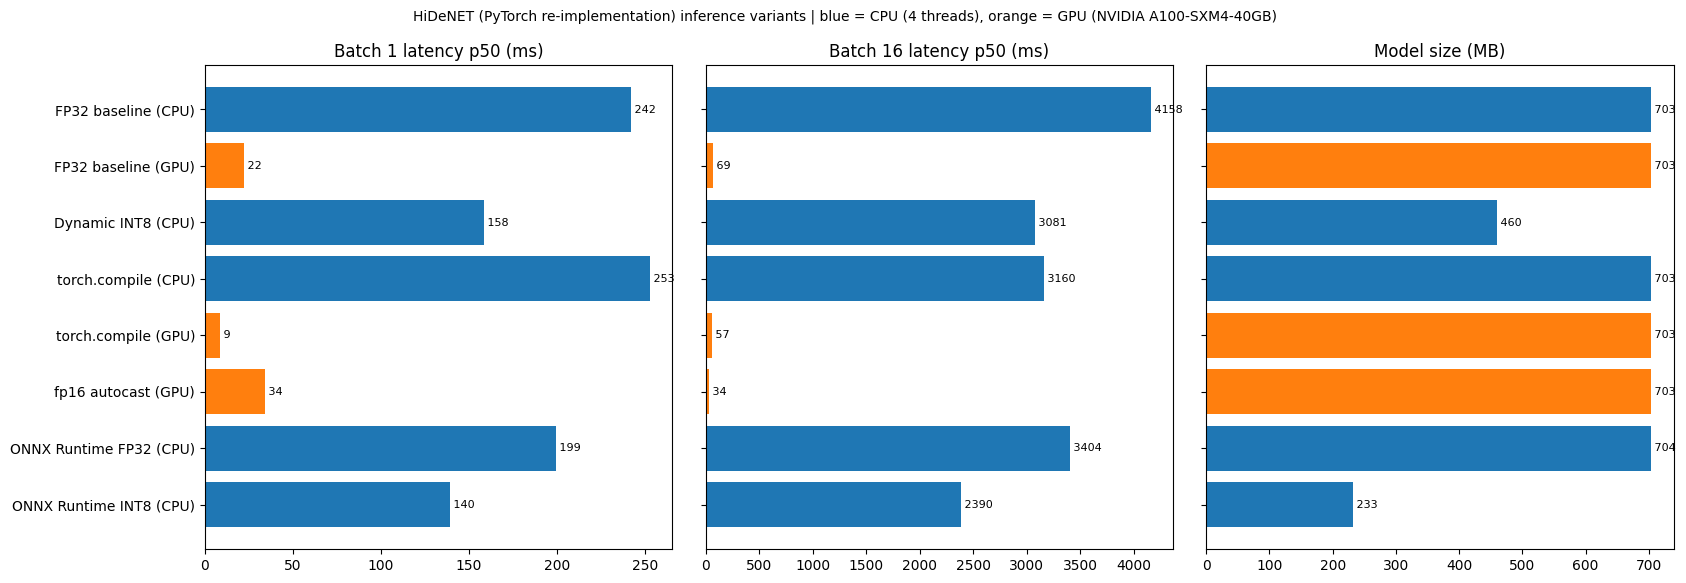

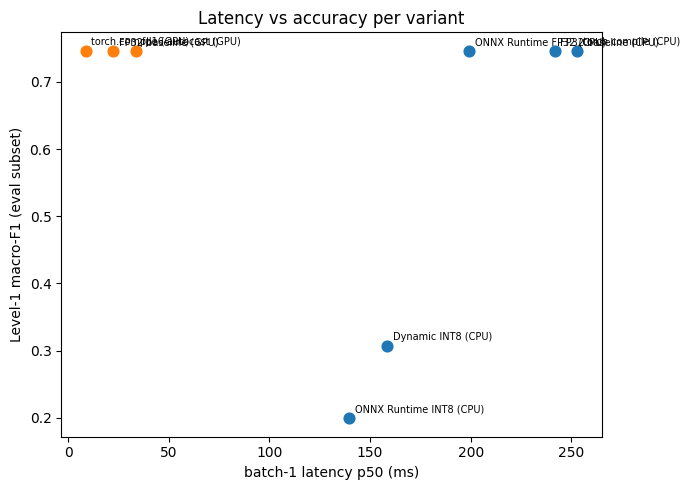

In [20]:
import matplotlib
import matplotlib.pyplot as plt

d = [r for r in ok]
names = [r["variant"] for r in d]
colors = ["tab:blue" if r["device"] == "cpu" else "tab:orange" for r in d]
fig, ax = plt.subplots(1, 3, figsize=(17, max(3.5, 0.55 * len(d) + 1.5)))
for a, key, title in zip(ax, ["bs1_p50", "bs16_p50", "size_mb"], ["Batch 1 latency p50 (ms)", "Batch 16 latency p50 (ms)", "Model size (MB)"]):
    vals = [r.get(key, 0) for r in d]
    a.barh(names, vals, color=colors); a.set_title(title); a.invert_yaxis()
    for i, v in enumerate(vals): a.text(v, i, f" {v:.0f}", va="center", fontsize=8)
for a in ax[1:]: a.set_yticklabels([])
fig.suptitle(f"HiDeNET (PyTorch re-implementation) inference variants | blue = CPU ({ENV['threads_used']} threads), orange = GPU ({ENV['gpu']})", fontsize=10)
plt.tight_layout(); plt.savefig(RES_DIR / "latency_size.png", dpi=150); plt.show()

fig, a = plt.subplots(figsize=(7, 5))
for r, c in zip(d, colors):
    a.scatter(r["bs1_p50"], r["f1_l1"], c=c, s=60)
    a.annotate(r["variant"], (r["bs1_p50"], r["f1_l1"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
a.set_xlabel("batch-1 latency p50 (ms)"); a.set_ylabel("Level-1 macro-F1 (eval subset)")
a.set_title("Latency vs accuracy per variant"); plt.tight_layout(); plt.savefig(RES_DIR / "latency_vs_f1.png", dpi=150); plt.show()

In [21]:
# ---- draft resume bullet from MEASURED numbers only ----
base_row = results[N_BASE]
cands = []
for r in ok:
    if r["device"] != "cpu" or r["variant"] == N_BASE:
        continue
    drop_l1 = (r["acc_l1"] - base_row["acc_l1"]) * 100
    cands.append({"variant": r["variant"],
                  "latency_cut_pct": round(100 * (1 - r["bs1_p50"] / base_row["bs1_p50"]), 1),
                  "thr16_gain_x": round(r["thr16_samples_s"] / base_row["thr16_samples_s"], 2),
                  "size_cut_pct": round(100 * (1 - r["size_mb"] / base_row["size_mb"]), 1),
                  "acc_l1_change_pts": round(drop_l1, 2),
                  "agree_l1": r.get("agree_l1"), "agree_l2": r.get("agree_l2"), "agree_l3": r.get("agree_l3")})
cd = pd.DataFrame(cands)
display(cd)
good = cd[cd.acc_l1_change_pts >= -1.0].sort_values("latency_cut_pct", ascending=False) if len(cd) else cd
if len(good):
    b = good.iloc[0]
    print("\nDRAFT (edit freely; every number below comes from your results table):\n")
    print(f"Optimized a DeBERTa-v3 + 1D-CNN multilevel classifier (PyTorch re-implementation of my IEEE SCEECS 2026 HiDeNET) for CPU inference via {b.variant}; "
          f"cut batch-1 p50 latency by {b.latency_cut_pct}% and model size by {b.size_cut_pct}% with a {b.acc_l1_change_pts:+.2f}-point change in Level-1 accuracy "
          f"(p50/p95 benchmarked at batch 1 and 16).")
    print("\nRules: only name tools whose rows are status=ok. If a variant failed or did not help, leave it out of the bullet and keep it in the README.")
else:
    print("No CPU variant stayed within 1 point of baseline Level-1 accuracy; report that honestly instead of a headline number.")

,variant,latency_cut_pct,thr16_gain_x,size_cut_pct,acc_l1_change_pts,agree_l1,agree_l2,agree_l3
0,Dynamic INT8 (CPU),34.5,1.35,34.6,-38.4,42.0,98.6,69.6
1,torch.compile (CPU),-4.6,1.31,0.0,0.0,100.0,100.0,100.0
2,ONNX Runtime FP32 (CPU),17.6,1.22,-0.1,0.0,100.0,100.0,100.0
3,ONNX Runtime INT8 (CPU),42.3,1.74,66.9,-51.6,28.8,98.6,68.2



DRAFT (edit freely; every number below comes from your results table):

Optimized a DeBERTa-v3 + 1D-CNN multilevel classifier (PyTorch re-implementation of my IEEE SCEECS 2026 HiDeNET) for CPU inference via ONNX Runtime FP32 (CPU); cut batch-1 p50 latency by 17.6% and model size by -0.1% with a +0.00-point change in Level-1 accuracy (p50/p95 benchmarked at batch 1 and 16).

Rules: only name tools whose rows are status=ok. If a variant failed or did not help, leave it out of the bullet and keep it in the README.


In [22]:
# ---- README draft (fill the TODO sections yourself; keep failures in) ----
met = json.loads((RES_DIR / "hidenet_reimpl_metrics.json").read_text())
paper_tbl = pd.DataFrame({
    "Level": [1, 2, 3],
    "Paper Hamming loss": PAPER_HAMMING,
    "Paper accuracy (1 - Hamming)": [round(1 - h, 4) for h in PAPER_HAMMING],
    "This re-implementation accuracy": [round(met[f"acc_l{i}"], 4) for i in (1, 2, 3)],
    "This re-implementation macro-F1": [round(met[f"f1_l{i}"], 3) for i in (1, 2, 3)],
})
prof_txt = ""
for p in sorted(RES_DIR.glob("profile_cpu_fp32_bs*_top_ops.csv")):
    prof_txt += f"\n**{p.stem.replace('_top_ops','')}**\n\n" + to_md(pd.read_csv(p)) + "\n"
fail_txt = "\n".join(f"- {r['variant']}: {r.get('notes','')}" for r in failed) or "- none"

readme = f"""# HiDeNET Inference Optimization

PyTorch re-implementation of HiDeNET (DeBERTa-v3-base + Conv1D multilevel classifier, IEEE SCEECS 2026) retrained on the same stratified split, then benchmarked under quantization, compilation and ONNX Runtime. The original TensorFlow checkpoint was not saved, so this repo does **not** optimize the published weights; metrics are within the table below of the paper's.

TODO: one-sentence headline result from the table.

## Setup
- Hardware: CPU `{ENV['cpu']}` ({ENV['cpu_count']} logical cores, {ENV['threads_used']} threads used), GPU `{ENV['gpu']}`
- Versions: torch {ENV['torch']}, transformers {ENV['transformers']}, onnxruntime {ENV.get('onnxruntime','n/a')}
- Model tag: `{TAG}` (backbone frozen: {FREEZE_BACKBONE}), max length {MAX_LEN}, fixed padding
- Protocol: same inputs for every variant; {WARMUP} warmup runs; timed runs: GPU {ITERS_GPU}, CPU batch 1 = {ITERS_CPU[1]}, CPU batch 16 = {ITERS_CPU[16]}; p50/p95; batch sizes 1 (latency) and 16 (throughput)
- Accuracy / agreement measured on a fixed random subset of {len(eval_pos)} held-out examples (same for all variants); agreement = % identical argmax vs FP32 CPU baseline

## Re-implementation vs paper (full test split, n={met['n_test']})
{to_md(paper_tbl)}

## Results
{to_md(table)}

![latency and size](results/{TAG}/latency_size.png)

## Profiling findings
{prof_txt}
Backbone share of CPU runtime: {json.dumps(breakdown)}

TODO: what dominated and whether it matched expectations.

## What worked / what didn't
Failed or skipped variants:
{fail_txt}

TODO: honest trade-offs (e.g. embeddings are ~half the parameters and are not touched by dynamic quantization; Conv1D is not quantized; small subset makes minority-class F1 noisy).

## Reproduce
Run `hidenet_inference_optimization.ipynb` top to bottom on a Colab T4 (Parts A to D). Dataset rows are not included.
"""
(RES_DIR / "README_draft.md").write_text(readme)
print(readme[:1800], "...\n\nSaved:", RES_DIR / "README_draft.md")

# HiDeNET Inference Optimization

PyTorch re-implementation of HiDeNET (DeBERTa-v3-base + Conv1D multilevel classifier, IEEE SCEECS 2026) retrained on the same stratified split, then benchmarked under quantization, compilation and ONNX Runtime. The original TensorFlow checkpoint was not saved, so this repo does **not** optimize the published weights; metrics are within the table below of the paper's.

TODO: one-sentence headline result from the table.

## Setup
- Hardware: CPU `Intel(R) Xeon(R) CPU @ 2.20GHz` (12 logical cores, 4 threads used), GPU `NVIDIA A100-SXM4-40GB`
- Versions: torch 2.11.0+cu130, transformers 5.18.0, onnxruntime 1.30.0
- Model tag: `deberta-v3-base_frozen` (backbone frozen: True), max length 256, fixed padding
- Protocol: same inputs for every variant; 10 warmup runs; timed runs: GPU 100, CPU batch 1 = 100, CPU batch 16 = 20; p50/p95; batch sizes 1 (latency) and 16 (throughput)
- Accuracy / agreement measured on a fixed random subset of 500 held-out examples (sa

In [23]:
# ---- bundle everything repo-ready (no dataset rows, no checkpoints) ----
req = ["torch", "transformers", "onnx", "onnxruntime", "sentencepiece", "scikit-learn", "numpy", "pandas"]
(RES_DIR / "requirements.txt").write_text("\n".join(f"{k}=={ENV[k]}" for k in ["torch", "transformers", "scikit-learn", "numpy", "pandas"] if k in ENV)
                                          + "\n" + "\n".join(f"{k}=={ENV[k]}" for k in ["onnx", "onnxruntime"] if k in ENV)
                                          + "\nsentencepiece\nmatplotlib\n")
bundle_dir = WORK_DIR / "repo_bundle"
if bundle_dir.exists(): shutil.rmtree(bundle_dir)
(bundle_dir / "results").mkdir(parents=True)
for f in RES_DIR.iterdir():
    if f.suffix in {".json", ".csv", ".md", ".txt", ".png"} and f.name != "baseline_logits_cpu_fp32.npz":
        shutil.copy(f, bundle_dir / "results" / f.name)
shutil.copy(RES_DIR / "README_draft.md", bundle_dir / "README.md")
shutil.copy(RES_DIR / "requirements.txt", bundle_dir / "requirements.txt")
(bundle_dir / ".gitignore").write_text("*.pt\n*.onnx\n*.npz\ntest_split.csv\ncleaned_dataframe.csv\n")
archive = shutil.make_archive(str(WORK_DIR / "hidenet_inference_optimization_bundle"), "zip", bundle_dir)
print("bundle:", archive)
if IN_COLAB:
    from google.colab import files
    files.download(archive)

bundle: /content/drive/MyDrive/Research/crypto-fire-analysis/hidenet-inference-optimization/hidenet_inference_optimization_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## After the run: checklist
1. Add the notebook itself to the repo (File → Download .ipynb) next to `README.md`, `requirements.txt` and `results/`.
2. Fill the three `TODO`s in the README with your own words, keeping any failed variants and why.
3. Use the resume bullet only with numbers from `results_table.md`, and only name tools whose rows say `ok`.
4. Interview prep: why dynamic quantization suits Linear-heavy transformers (and why the embedding table and Conv1D are untouched), dynamic vs static vs QAT, what the profiler showed vs your expectation, batch 1 vs 16 behaviour, what you would try next (static quantization with calibration, QAT, distillation, TensorRT).

In [24]:
for f in ["environment.json", "hidenet_reimpl_metrics.json", "hidenet_reimpl_classification_reports.txt"]:
    print("=====", f)
    print((RES_DIR / f).read_text())
print("===== last 3 epochs")
for r in json.loads((RES_DIR / "train_history.json").read_text())[-3:]:
    print(r)
print("===== split")
print(len(df), len(fit_idx), len(val_idx), len(test_idx))

===== environment.json
{
  "cpu": "Intel(R) Xeon(R) CPU @ 2.20GHz",
  "cpu_count": 12,
  "threads_used": 4,
  "gpu": "NVIDIA A100-SXM4-40GB",
  "python": "3.13.15",
  "torch": "2.11.0+cu130",
  "transformers": "5.18.0",
  "scikit-learn": "1.6.1",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "onnxruntime": "1.30.0",
  "onnx": "1.23.1"
}
===== hidenet_reimpl_metrics.json
{
  "acc_l1": 0.8046411225040475,
  "f1_l1": 0.7625488976088244,
  "acc_l2": 0.8834322719913653,
  "f1_l2": 0.41030801483631674,
  "acc_l3": 0.8332433890987587,
  "f1_l3": 0.6430661750641637,
  "n_test": 1853,
  "tag": "deberta-v3-base_frozen"
}
===== hidenet_reimpl_classification_reports.txt
=== Level 1 ===
              precision    recall  f1-score   support

           0       0.67      0.66      0.66       351
           1       0.77      0.74      0.76       422
           2       0.86      0.88      0.87      1080

    accuracy                           0.80      1853
   macro avg       0.77      0.76      0.76     

In [25]:
print(json.dumps(results, indent=1))
print("===== breakdown")
print(json.dumps(breakdown, indent=1))
for p in sorted(RES_DIR.glob("profile_*_top_ops.csv")):
    print("=====", p.name)
    print(p.read_text())

{
 "FP32 baseline (CPU)": {
  "variant": "FP32 baseline (CPU)",
  "device": "cpu",
  "status": "ok",
  "size_mb": 703.4,
  "threads": 4,
  "bs1_p50": 241.81,
  "bs1_p95": 316.38,
  "bs16_p50": 4157.92,
  "bs16_p95": 4241.55,
  "thr16_samples_s": 3.85,
  "acc_l1": 0.78,
  "f1_l1": 0.7466,
  "acc_l2": 0.88,
  "f1_l2": 0.4074,
  "acc_l3": 0.864,
  "f1_l3": 0.6928,
  "agree_l1": 100.0,
  "maxdiff_l1": 0.0,
  "agree_l2": 100.0,
  "maxdiff_l2": 0.0,
  "agree_l3": 100.0,
  "maxdiff_l3": 0.0,
  "notes": "reference; agreement/maxdiff columns are measured against this row"
 },
 "FP32 baseline (GPU)": {
  "variant": "FP32 baseline (GPU)",
  "device": "cuda",
  "status": "ok",
  "size_mb": 703.4,
  "threads": null,
  "bs1_p50": 22.27,
  "bs1_p95": 23.85,
  "bs16_p50": 69.4,
  "bs16_p95": 69.55,
  "thr16_samples_s": 230.54,
  "acc_l1": 0.78,
  "f1_l1": 0.7466,
  "acc_l2": 0.88,
  "f1_l2": 0.4074,
  "acc_l3": 0.864,
  "f1_l3": 0.6928,
  "agree_l1": 100.0,
  "maxdiff_l1": 0.000268,
  "agree_l2": 100.

In [26]:
torch._dynamo.reset()
qm_re = torch.ao.quantization.quantize_dynamic(copy.deepcopy(base).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
cm_re = torch.compile(base)
sess_fp, sess_q = make_session(ONNX_FP32), make_session(ONNX_INT8)
runners = {
    "FP32 baseline (CPU)": lambda bs: torch_fn_factory(base, "cpu")(bs),
    "Dynamic INT8 (CPU)": lambda bs: torch_fn_factory(qm_re, "cpu")(bs),
    "torch.compile (CPU)": lambda bs: torch_fn_factory(cm_re, "cpu")(bs),
    "ONNX Runtime FP32 (CPU)": lambda bs: ort_factory(sess_fp)(bs),
    "ONNX Runtime INT8 (CPU)": lambda bs: ort_factory(sess_q)(bs),
}
def timed(fn, warmup, iters):
    for _ in range(warmup): fn()
    ts = []
    for _ in range(iters):
        t = time.perf_counter(); fn(); ts.append((time.perf_counter() - t) * 1000)
    return ts

PLAN = {1: (5, 20), 16: (2, 6)}          # (warmup, timed) per round
names = list(runners)
pool = {n: {1: [], 16: []} for n in names}
for rnd in range(3):
    for n in names[rnd:] + names[:rnd]:   # rotate order each round
        for bs, (w, it) in PLAN.items():
            pool[n][bs] += timed(runners[n](bs), w, it)
    print("round", rnd + 1, "done")

for n in names:
    r = results[n]
    r.setdefault("first_pass_bs1_p50", r["bs1_p50"]); r.setdefault("first_pass_bs16_p50", r["bs16_p50"])
    for bs in (1, 16):
        r[f"bs{bs}_p50"] = round(float(np.percentile(pool[n][bs], 50)), 2)
        r[f"bs{bs}_p95"] = round(float(np.percentile(pool[n][bs], 95)), 2)
    r["thr16_samples_s"] = round(16 / (r["bs16_p50"] / 1000), 2)
    r["notes"] = r["notes"].split(" | re-measured")[0] + " | re-measured interleaved, 3 rounds, pooled"
save_results()
b = results["FP32 baseline (CPU)"]
for n in names:
    r = results[n]
    print(f"{n:26s} bs1 {r['bs1_p50']:7.1f} ms ({b['bs1_p50']/r['bs1_p50']:.2f}x) | bs16 {r['bs16_p50']:8.1f} ms ({b['bs16_p50']/r['bs16_p50']:.2f}x) | first-pass bs16 {r['first_pass_bs16_p50']}")

round 1 done
round 2 done
round 3 done
FP32 baseline (CPU)        bs1   245.4 ms (1.00x) | bs16   4147.3 ms (1.00x) | first-pass bs16 4157.92
Dynamic INT8 (CPU)         bs1   165.2 ms (1.49x) | bs16   3414.0 ms (1.21x) | first-pass bs16 3080.66
torch.compile (CPU)        bs1   249.4 ms (0.98x) | bs16   3763.1 ms (1.10x) | first-pass bs16 3160.02
ONNX Runtime FP32 (CPU)    bs1   203.9 ms (1.20x) | bs16   3403.7 ms (1.22x) | first-pass bs16 3404.21
ONNX Runtime INT8 (CPU)    bs1   136.3 ms (1.80x) | bs16   2387.6 ms (1.74x) | first-pass bs16 2390.16


In [27]:
# (1) where does the INT8 error enter? compare backbone outputs and head features, FP32 vs INT8
qm_d = torch.ao.quantization.quantize_dynamic(copy.deepcopy(base).cpu().eval(), {nn.Linear}, dtype=torch.qint8)
ids, mask = torch.from_numpy(EV_IDS[:16]), torch.from_numpy(EV_MASK[:16])
with torch.inference_mode():
    h_fp = base.backbone(input_ids=ids, attention_mask=mask).last_hidden_state
    h_q = qm_d.backbone(input_ids=ids, attention_mask=mask).last_hidden_state
    def head_feats(h):
        return h[:, 0], F.relu(base.conv(h.transpose(1, 2))).max(dim=2).values
    (cf, pf), (cq, pq) = head_feats(h_fp), head_feats(h_q)
cos = lambda a, b: F.cosine_similarity(a, b, dim=1).mean().item()
rel = (h_q - h_fp).norm(dim=-1) / h_fp.norm(dim=-1)
real = mask.bool()
print(f"CLS cosine {cos(cf, cq):.4f} | pooled-conv cosine {cos(pf, pq):.4f}")
print(f"relative hidden-state error: real tokens {rel[real].mean().item():.3f}",
      f"| padding tokens {rel[~real].mean().item():.3f}" if (~real).any() else "")
del qm_d; gc.collect()

# (2) torch: narrower scopes and per-channel weight scales (192 eval samples each)
PCQ = torch.ao.quantization.per_channel_dynamic_qconfig
def lin_names(pred):
    return {n for n, m in base.named_modules() if isinstance(m, nn.Linear) and pred(n)}
scopes = {
    "backbone only (head FP32)":       lin_names(lambda n: n.startswith("backbone.")),
    "head only (backbone FP32)":       lin_names(lambda n: not n.startswith("backbone.")),
    "FFN only":                        lin_names(lambda n: n.startswith("backbone.") and (".intermediate.dense" in n or (n.endswith(".output.dense") and ".attention." not in n))),
    "attention only":                  lin_names(lambda n: ".attention." in n),
}
specs = {k: v for k, v in scopes.items()}
specs["all Linear, per-channel"] = {nn.Linear: PCQ}
specs["backbone only, per-channel"] = {n: PCQ for n in scopes["backbone only (head FP32)"]}
N_D = 192
rows = []
for label, spec in specs.items():
    q = torch.ao.quantization.quantize_dynamic(copy.deepcopy(base).cpu().eval(), spec, dtype=torch.qint8)
    lg = predict_torch(q, EV_IDS[:N_D], EV_MASK[:N_D], "cpu", bs=16)
    ag = [float((lg[i].argmax(1) == BASE_LOGITS[i][:N_D].argmax(1)).mean()) * 100 for i in range(3)]
    rows.append({"scope": label, "agree_L1 %": round(ag[0], 1), "agree_L2 %": round(ag[1], 1), "agree_L3 %": round(ag[2], 1),
                 "bs1 p50 ms": round(bench(torch_fn_factory(q, "cpu")(1), 3, 15)[0], 1)})
    del q; gc.collect()

# (3) ORT: MatMul weights only (leaves the embedding table alone), per-tensor vs per-channel
for label, kw in {"ORT MatMul only": {}, "ORT MatMul only, per-channel": {"per_channel": True}}.items():
    out = ONNX_DIR / "diag.onnx"
    quantize_dynamic(str(ONNX_FP32), str(out), weight_type=QuantType.QInt8, op_types_to_quantize=["MatMul"], **kw)
    s = make_session(out)
    lg = predict_ort(s, EV_IDS[:N_D], EV_MASK[:N_D])
    ag = [float((lg[i].argmax(1) == BASE_LOGITS[i][:N_D].argmax(1)).mean()) * 100 for i in range(3)]
    rows.append({"scope": f"{label} ({os.path.getsize(out)/2**20:.0f} MB)", "agree_L1 %": round(ag[0], 1), "agree_L2 %": round(ag[1], 1),
                 "agree_L3 %": round(ag[2], 1), "bs1 p50 ms": round(bench(ort_factory(s)(1), 3, 15)[0], 1)})
    del s; gc.collect()
diag = pd.DataFrame(rows); display(diag); diag.to_csv(RES_DIR / "quant_diagnosis.csv", index=False)

CLS cosine 0.9811 | pooled-conv cosine 0.8599
relative hidden-state error: real tokens 0.796 | padding tokens 1.338


,scope,agree_L1 %,agree_L2 %,agree_L3 %,bs1 p50 ms
0,backbone only (head FP32),39.6,97.4,73.4,164.2
1,head only (backbone FP32),97.9,100.0,99.0,237.4
2,FFN only,42.7,97.4,72.4,195.6
3,attention only,94.8,100.0,93.8,205.4
4,"all Linear, per-channel",52.1,94.3,72.4,156.9
5,"backbone only, per-channel",52.1,94.8,72.4,159.8
6,ORT MatMul only (515 MB),26.0,97.4,72.4,131.0
7,"ORT MatMul only, per-channel (515 MB)",63.0,96.4,75.0,133.1


In [28]:
def lin_names(pred):
    return {n for n, m in base.named_modules() if isinstance(m, nn.Linear) and pred(n)}
is_ffn_in  = lambda n: n.startswith("backbone.") and n.endswith(".intermediate.dense")
is_ffn_out = lambda n: n.startswith("backbone.") and n.endswith(".output.dense") and ".attention." not in n

def eval_scope(names_q, n_samples=192, do_bench=True):
    q = torch.ao.quantization.quantize_dynamic(copy.deepcopy(base).cpu().eval(), names_q, dtype=torch.qint8)
    lg = predict_torch(q, EV_IDS[:n_samples], EV_MASK[:n_samples], "cpu", bs=16)
    ag = [float((lg[i].argmax(1) == BASE_LOGITS[i][:n_samples].argmax(1)).mean()) * 100 for i in range(3)]
    t = bench(torch_fn_factory(q, "cpu")(1), 3, 15)[0] if do_bench else None
    del q; gc.collect()
    return ag, t

all_lin, rows = lin_names(lambda n: True), []
for label, names_q in {
    "FFN intermediate.dense only": lin_names(is_ffn_in),
    "FFN output.dense only": lin_names(is_ffn_out),
    "everything except FFN output.dense": all_lin - lin_names(is_ffn_out),
}.items():
    ag, t = eval_scope(names_q)
    rows.append({"scope": label, "n_linear": len(names_q), "agree_L1 %": round(ag[0], 1),
                 "agree_L2 %": round(ag[1], 1), "agree_L3 %": round(ag[2], 1), "bs1 p50 ms": round(t, 1)})
display(pd.DataFrame(rows))

# per-layer scan: quantize ONLY layer i's FFN output.dense
scan = []
for i in range(12):
    ag, _ = eval_scope(lin_names(lambda n, i=i: is_ffn_out(n) and f".layer.{i}." in n), n_samples=96, do_bench=False)
    scan.append({"layer": i, "agree_L1 %": round(ag[0], 1), "agree_L3 %": round(ag[2], 1)})
display(pd.DataFrame(scan))

# ORT: MatMul only, per-channel, FFN output.dense nodes excluded
import onnx
om = onnx.load(str(ONNX_FP32), load_external_data=False)
mm = [n.name for n in om.graph.node if n.op_type == "MatMul"]
ffn_nodes = [n for n in mm if n.endswith("output/dense/MatMul") and "/attention/" not in n]
print(len(mm), "MatMul nodes;", len(ffn_nodes), "FFN output.dense nodes;", ffn_nodes[:2])
if ffn_nodes:
    out = ONNX_DIR / "diag_excl.onnx"
    quantize_dynamic(str(ONNX_FP32), str(out), weight_type=QuantType.QInt8, op_types_to_quantize=["MatMul"],
                     per_channel=True, nodes_to_exclude=ffn_nodes)
    s = make_session(out)
    lg = predict_ort(s, EV_IDS[:192], EV_MASK[:192])
    ag = [float((lg[i].argmax(1) == BASE_LOGITS[i][:192].argmax(1)).mean()) * 100 for i in range(3)]
    print(f"ORT excl. FFN output.dense: {os.path.getsize(out)/2**20:.0f} MB | agree {ag} | bs1 p50 {bench(ort_factory(s)(1), 3, 15)[0]:.1f} ms")
else:
    print(mm[:8])   # node names did not match my pattern: paste this line to me

,scope,n_linear,agree_L1 %,agree_L2 %,agree_L3 %,bs1 p50 ms
0,FFN intermediate.dense only,12,65.6,97.4,77.1,221.5
1,FFN output.dense only,12,26.0,97.4,74.0,216.8
2,everything except FFN output.dense,64,67.7,97.4,76.0,190.0


,layer,agree_L1 %,agree_L3 %
0,0,90.6,95.8
1,1,86.5,95.8
2,2,80.2,91.7
3,3,72.9,79.2
4,4,60.4,72.9
5,5,78.1,80.2
6,6,61.5,75.0
7,7,83.3,83.3
8,8,78.1,86.5
9,9,86.5,94.8


144 MatMul nodes; 12 FFN output.dense nodes; ['/m/backbone/encoder/layer.0/output/dense/MatMul', '/m/backbone/encoder/layer.1/output/dense/MatMul']


ORT excl. FFN output.dense: 596 MB | agree [84.375, 97.91666666666666, 93.75] | bs1 p50 167.9 ms


In [29]:
# (1) length-aware inference: trim each batch to its longest real sequence, FP32 CPU
lens = EV_MASK.sum(1)
print("real tokens: mean %.0f | median %.0f | p95 %.0f | max %d" % (lens.mean(), np.median(lens), np.percentile(lens, 95), lens.max()))
assert (EV_MASK[:, :int(lens.max())].sum() == EV_MASK.sum()), "padding is not on the right side"

def predict_trim(m, ids, mask, bs):
    outs, ts = [[], [], []], []
    for i in range(0, len(ids), bs):
        L = int(mask[i:i+bs].sum(1).max())
        a, b = torch.from_numpy(ids[i:i+bs, :L]), torch.from_numpy(mask[i:i+bs, :L])
        t = time.perf_counter()
        with torch.inference_mode():
            o = m(a, b)
        ts.append((time.perf_counter() - t) * 1000)
        for k in range(3): outs[k].append(o[k].float().numpy())
    return tuple(np.concatenate(x) for x in outs), ts

for bs in (1, 16):
    predict_trim(base, EV_IDS[:16], EV_MASK[:16], bs)          # warm-up
    lg, ts = predict_trim(base, EV_IDS, EV_MASK, bs)
    ag = [float((lg[i].argmax(1) == BASE_LOGITS[i].argmax(1)).mean()) * 100 for i in range(3)]
    m_ = head_metrics(lg, EV_Y)
    print(f"bs{bs}: agreement vs fixed-256 FP32 L1/L2/L3 = {ag[0]:.1f}/{ag[1]:.1f}/{ag[2]:.1f} % | acc_l1 {m_['acc_l1']:.3f} "
          f"| per-call p50 {np.percentile(ts, 50):.1f} ms, p95 {np.percentile(ts, 95):.1f} ms "
          f"(fixed-256 baseline p50: {results['FP32 baseline (CPU)'][f'bs{bs}_p50']} ms)")

# (2) record the ORT mitigation attempt as a proper (documented, partial) result row
import onnx
om = onnx.load(str(ONNX_FP32), load_external_data=False)
ffn_nodes = [n.name for n in om.graph.node if n.op_type == "MatMul" and n.name.endswith("output/dense/MatMul") and "/attention/" not in n.name]
out = ONNX_DIR / "hidenet_int8_ffnout_fp32.onnx"
quantize_dynamic(str(ONNX_FP32), str(out), weight_type=QuantType.QInt8, op_types_to_quantize=["MatMul"],
                 per_channel=True, nodes_to_exclude=ffn_nodes)
s = make_session(out)
N = "ONNX Runtime INT8 (FFN output FP32, per-channel)"
lat = run_latency(ort_factory(s), "cpu")
logits = predict_ort(s, EV_IDS, EV_MASK)
record(N, "cpu", os.path.getsize(out) / 2 ** 20, lat, logits,
       notes="mitigation attempt: MatMul-only, per-channel, 12 FFN output.dense MatMuls kept FP32; still changes many Level-1 predictions")
show()

real tokens: mean 42 | median 20 | p95 170 | max 256
bs1: agreement vs fixed-256 FP32 L1/L2/L3 = 92.8/99.6/95.4 % | acc_l1 0.768 | per-call p50 111.8 ms, p95 185.1 ms (fixed-256 baseline p50: 245.4 ms)
bs16: agreement vs fixed-256 FP32 L1/L2/L3 = 95.2/99.2/97.6 % | acc_l1 0.764 | per-call p50 2750.2 ms, p95 4009.9 ms (fixed-256 baseline p50: 4147.26 ms)


  bs1: p50 162.3 ms | p95 172.4 ms
  bs16: p50 2778.3 ms | p95 2806.5 ms


,variant,status,size_mb,bs1_p50,bs1_p95,bs16_p50,bs16_p95,acc_l1,acc_l2,acc_l3,agree_l1,agree_l2,agree_l3
0,FP32 baseline (CPU),ok,703.4,245.40,253.89,4147.26,4198.33,0.780,0.880,0.864,100.0,100.0,100.0
1,FP32 baseline (GPU),ok,703.4,22.27,23.85,69.40,69.55,0.780,0.880,0.864,100.0,100.0,100.0
2,Dynamic INT8 (CPU),ok,459.7,165.20,169.32,3413.96,3462.91,0.396,0.872,0.660,42.0,98.6,69.6
3,torch.compile (CPU),ok,703.4,249.39,257.25,3763.05,3825.23,0.780,0.880,0.864,100.0,100.0,100.0
4,torch.compile (GPU),ok,703.4,8.80,10.08,57.39,57.57,0.780,0.880,0.864,100.0,100.0,100.0
5,fp16 autocast (GPU),ok,703.4,33.90,36.52,34.18,34.75,0.780,0.880,0.864,100.0,100.0,100.0
6,ONNX Runtime FP32 (CPU),ok,704.2,203.93,221.42,3403.74,3479.21,0.780,0.880,0.864,100.0,100.0,100.0
7,ONNX Runtime INT8 (CPU),ok,232.6,136.34,139.62,2387.56,2422.31,0.264,0.872,0.652,28.8,98.6,68.2
8,"ONNX Runtime INT8 (FFN output FP32, per-channel)",ok,596.3,162.32,172.40,2778.32,2806.52,0.736,0.870,0.842,84.4,99.0,93.8


In [30]:
bc, bg = results["FP32 baseline (CPU)"], results["FP32 baseline (GPU)"]
lossless = lambda r: r["status"] == "ok" and all(r.get(f"agree_l{i}", 0) >= 99.9 for i in (1, 2, 3))
facts = []
for r in results.values():
    if not lossless(r) or r["variant"].startswith("FP32 baseline"): continue
    b = bg if r["device"] == "cuda" else bc
    facts.append({"variant": r["variant"],
                  "bs1 latency cut %": round(100 * (1 - r["bs1_p50"] / b["bs1_p50"]), 1),
                  "bs1 ms": f"{b['bs1_p50']:.1f} -> {r['bs1_p50']:.1f}",
                  "bs16 throughput x": round(r["thr16_samples_s"] / b["thr16_samples_s"], 2)})
display(pd.DataFrame(facts))
g, h, o = results["torch.compile (GPU)"], results["fp16 autocast (GPU)"], results["ONNX Runtime FP32 (CPU)"]
print(f"Optimized inference of a DeBERTa-v3 + 1D-CNN multilevel classifier (PyTorch re-implementation of my IEEE SCEECS 2026 HiDeNET): "
      f"torch.compile cut A100 batch-1 latency {100*(1-g['bs1_p50']/bg['bs1_p50']):.0f}% ({bg['bs1_p50']:.1f} to {g['bs1_p50']:.1f} ms), "
      f"fp16 autocast raised batch-16 throughput {h['thr16_samples_s']/bg['thr16_samples_s']:.1f}x, and ONNX Runtime cut CPU latency "
      f"{100*(1-o['bs1_p50']/bc['bs1_p50']):.0f}%, all with 100% prediction agreement; traced the INT8 quantization accuracy collapse "
      f"to FFN quantization error accumulating across layers.")

,variant,bs1 latency cut %,bs1 ms,bs16 throughput x
0,torch.compile (CPU),-1.6,245.4 -> 249.4,1.10
1,torch.compile (GPU),60.5,22.3 -> 8.8,1.21
2,fp16 autocast (GPU),-52.2,22.3 -> 33.9,2.03
3,ONNX Runtime FP32 (CPU),16.9,245.4 -> 203.9,1.22


Optimized inference of a DeBERTa-v3 + 1D-CNN multilevel classifier (PyTorch re-implementation of my IEEE SCEECS 2026 HiDeNET): torch.compile cut A100 batch-1 latency 60% (22.3 to 8.8 ms), fp16 autocast raised batch-16 throughput 2.0x, and ONNX Runtime cut CPU latency 17%, all with 100% prediction agreement; traced the INT8 quantization accuracy collapse to FFN quantization error accumulating across layers.
